# 🎯 Darts - Forecasting Avancé pour Nappes Phréatiques

## Objectif
Utiliser la librairie **Darts** (https://github.com/unit8co/darts) pour la prévision des niveaux piézométriques.

Darts est une librairie Python complète pour la modélisation de séries temporelles, offrant :
- **Plus de 40 modèles** (statistiques, ML, deep learning)
- **Gestion native des covariates** (variables exogènes)
- **Backtesting et validation temporelle** automatiques
- **API unifiée** pour tous les modèles

## Pourquoi Darts pour les nappes phréatiques ?

Les nappes phréatiques ont des caractéristiques spécifiques :
1. **Forte autocorrélation** - Le niveau d'aujourd'hui dépend fortement d'hier
2. **Influences exogènes** - Précipitations, température, évapotranspiration
3. **Délais temporels** - La pluie influence la nappe avec 2-3 semaines de retard
4. **Saisonnalité** - Cycles annuels de recharge/décharge

Les modèles génériques (DLinear, PatchTST) échouent car ils font du **pattern matching** au lieu de modéliser ces relations causales.

## Modèles testés

Nous comparerons 4 modèles state-of-the-art :

### 1. **TFT (Temporal Fusion Transformer)**
- Architecture avec **attention multi-horizon**
- Apprend automatiquement l'importance des covariates
- Interprétable via attention weights
- **Loss** : Quantile Loss (prédictions probabilistes)

### 2. **N-BEATS (Neural Basis Expansion Analysis)**
- Décomposition automatique **tendance + saisonnalité**
- Architecture doubly residual
- Pas besoin de preprocessing
- **Loss** : MAPE ou MAE

### 3. **TCN (Temporal Convolutional Network)**
- Convolutions causales pour séries temporelles
- Champ réceptif large (regarde loin dans le passé)
- Très rapide à entraîner
- **Loss** : MSE

### 4. **LSTM (Long Short-Term Memory)**
- Baseline classique pour séries temporelles
- Mémoire à long terme
- Gère bien les dépendances temporelles
- **Loss** : MSE

## Structure du notebook

1. Installation et imports
2. Chargement et exploration des données
3. Préparation des séries temporelles (Darts format)
4. Entraînement des modèles avec logging
5. Évaluation et comparaison
6. Visualisations et interprétation
7. Analyse des erreurs

---
## 1. Installation et Imports

In [1]:
import sys
import os
import shutil
from pathlib import Path

# Se placer à la racine du projet (idempotent)
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
    
# Vérifier qu'on est bien à la racine
if not os.path.exists('data/piezos'):
    raise RuntimeError(f"Erreur: dossier 'data/piezos' introuvable. Répertoire actuel: {os.getcwd()}")

sys.path.append('.')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Darts imports
from darts import TimeSeries
from darts.models import (
    TFTModel,           # Temporal Fusion Transformer
    NBEATSModel,        # N-BEATS
    TCNModel,           # Temporal Convolutional Network
    RNNModel,           # LSTM/GRU
)
from darts.metrics import mape, mae, rmse, mse, r2_score
from darts.dataprocessing.transformers import Scaler

# PyTorch Lightning pour les callbacks personnalisés
from pytorch_lightning.callbacks import EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger

import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)

print(f"Device: {device}")
print(f"Working directory: {os.getcwd()}")

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md


Device: cuda
Working directory: e:\junon-time-series


---
## 2. Chargement et Exploration des Données

### Structure des données
Nos données piézométriques contiennent :
- **Target** : `level` (niveau de la nappe)
- **Covariates** : `rain`, `temp`, `etp` (évapotranspiration potentielle)

### Exploration visuelle
Nous allons visualiser :
1. La série temporelle complète
2. Les corrélations entre variables
3. Les autocorrélations (ACF/PACF)

In [2]:
# Chargement des données
df = pd.read_csv('data/piezos/piezo1.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

# Renommer les colonnes pour cohérence
df = df.rename(columns={
    'PRELIQ_Q': 'rain',
    'T_Q': 'temp',
    'ETP_Q': 'etp'
})

print("Dataset shape:", df.shape)
print("\nPremières lignes:")
print(df.head())
print("\nStatistiques descriptives:")
print(df.describe())

# Gestion des valeurs manquantes
if df.isnull().sum().any():
    print("\nValeurs manquantes détectées - interpolation...")
    df = df.interpolate(method='linear')
else:
    print("\nPas de valeurs manquantes")

print(f"\nPériode: {df.index.min().strftime('%Y-%m-%d')} à {df.index.max().strftime('%Y-%m-%d')}")
print(f"Nombre de jours: {(df.index.max() - df.index.min()).days}")

Dataset shape: (10865, 4)

Premières lignes:
            level  rain  temp  etp
date                              
1994-08-03  92.21   0.0  24.8  6.6
1994-08-04  91.10   0.0  25.6  5.9
1994-08-05  91.07   0.1  24.1  3.5
1994-08-06  92.15   0.3  24.5  5.1
1994-08-07  92.22  10.7  23.0  4.2

Statistiques descriptives:
              level          rain          temp           etp
count  10865.000000  10865.000000  10865.000000  10865.000000
mean      91.652942      2.047428     11.619770      2.166553
std        0.770248      4.168530      6.605714      1.585955
min       89.950000      0.000000     -9.400000      0.000000
25%       91.060000      0.000000      6.900000      0.800000
50%       91.580000      0.100000     11.600000      1.800000
75%       92.160000      2.200000     16.700000      3.200000
max       94.280000     66.200000     30.800000      9.000000

Pas de valeurs manquantes

Période: 1994-08-03 à 2024-05-01
Nombre de jours: 10864


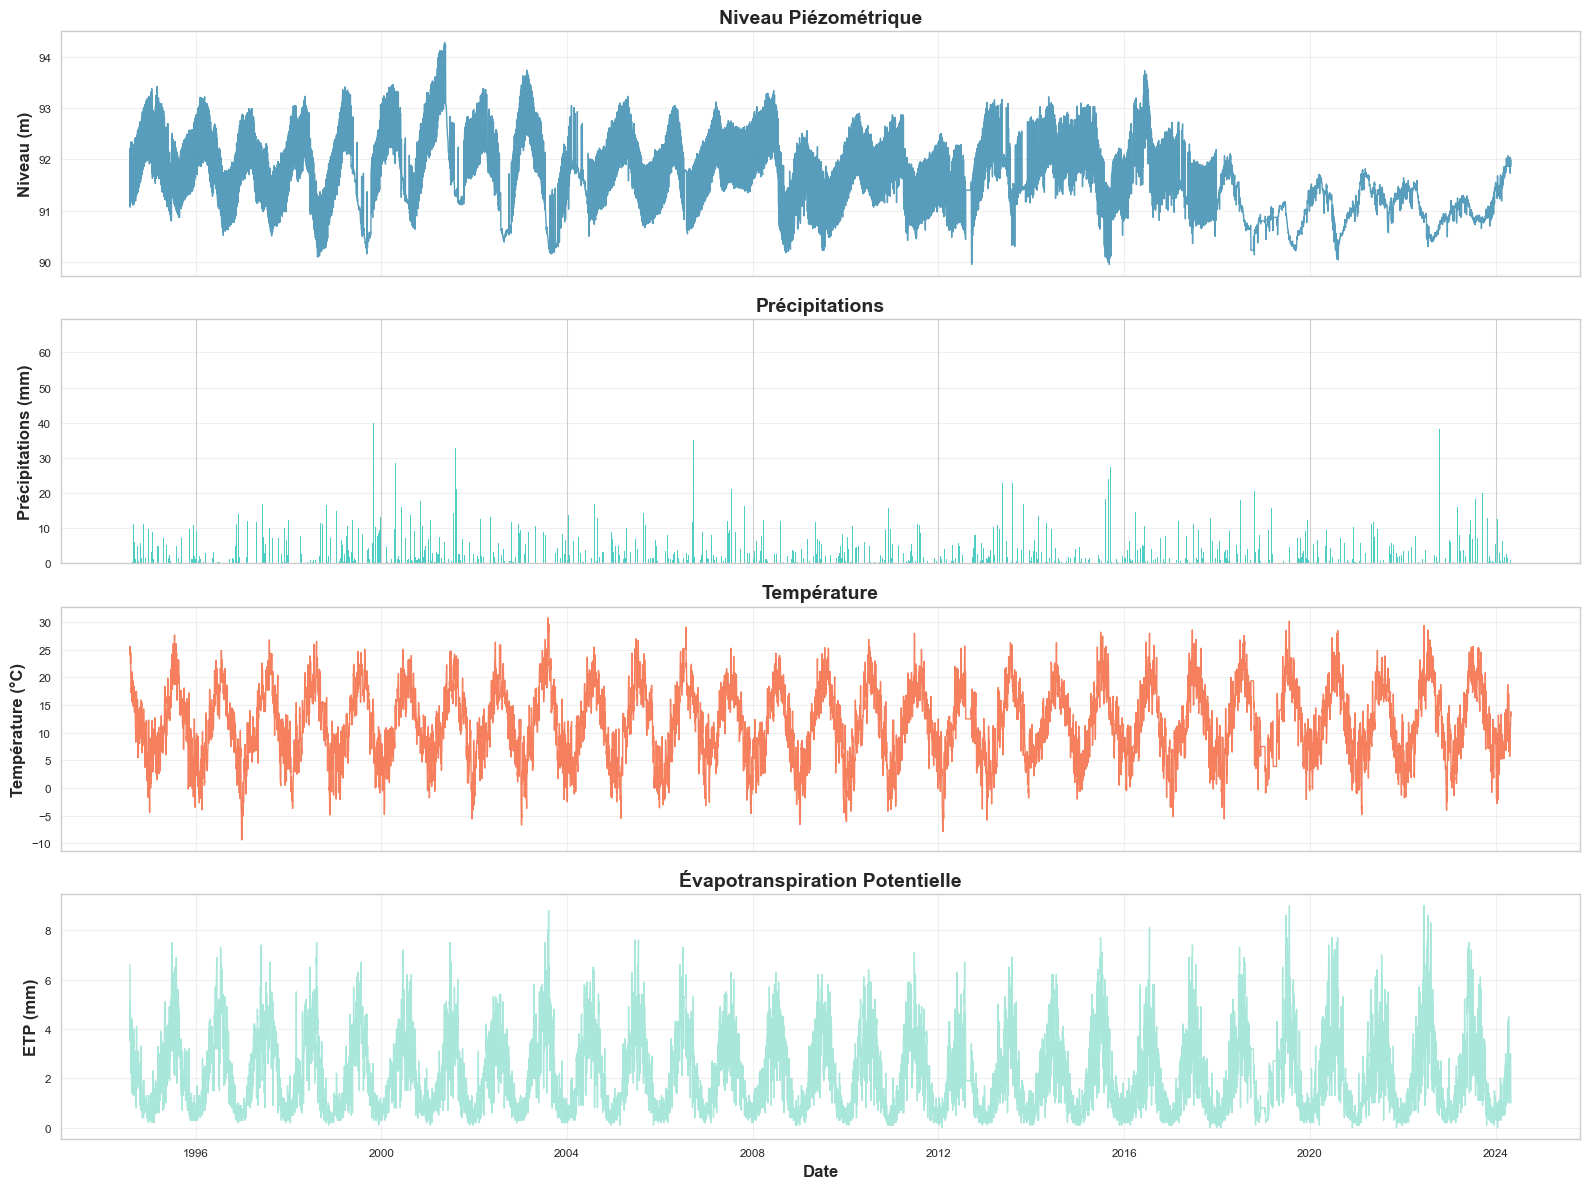

In [3]:
# Créer le dossier figs s'il n'existe pas
os.makedirs('figs', exist_ok=True)

# Visualisation des séries temporelles
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

# Niveau piézométrique
axes[0].plot(df.index, df['level'], linewidth=1, color='#2E86AB', alpha=0.8)
axes[0].set_ylabel('Niveau (m)', fontsize=12, fontweight='bold')
axes[0].set_title('Niveau Piézométrique', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Précipitations
axes[1].bar(df.index, df['rain'], width=1, color='#4ECDC4', alpha=1.0, edgecolor='none')
axes[1].set_ylabel('Précipitations (mm)', fontsize=12, fontweight='bold')
axes[1].set_title('Précipitations', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Température
axes[2].plot(df.index, df['temp'], linewidth=1, color='#F46036', alpha=0.8)
axes[2].set_ylabel('Température (°C)', fontsize=12, fontweight='bold')
axes[2].set_title('Température', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

# ETP
axes[3].plot(df.index, df['etp'], linewidth=1, color='#95E1D3', alpha=0.8)
axes[3].set_ylabel('ETP (mm)', fontsize=12, fontweight='bold')
axes[3].set_title('Évapotranspiration Potentielle', fontsize=14, fontweight='bold')
axes[3].set_xlabel('Date', fontsize=12, fontweight='bold')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figs/darts_timeseries_overview.png', dpi=300, bbox_inches='tight')
plt.show()

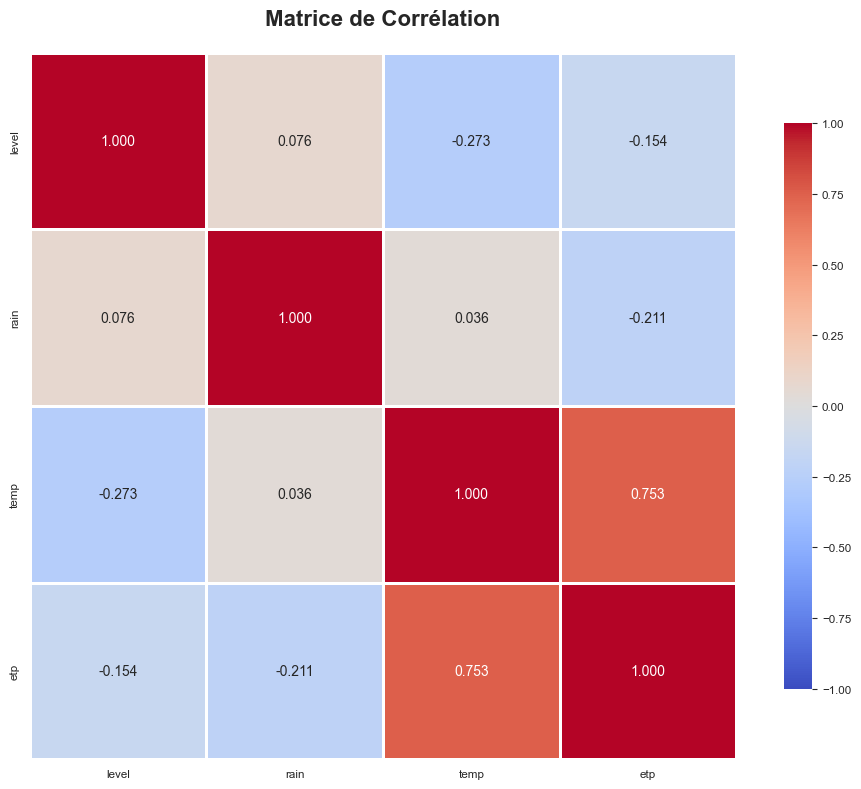


Corrélations avec le niveau piézométrique:
level    1.000000
rain     0.076345
etp     -0.153702
temp    -0.272861
Name: level, dtype: float64


In [4]:
# Matrice de corrélation
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.3f', vmin=-1, vmax=1)
plt.title('Matrice de Corrélation', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('figs/darts_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCorrélations avec le niveau piézométrique:")
print(correlation_matrix['level'].sort_values(ascending=False))

---
## 3. Préparation des Séries Temporelles (Format Darts)

### Format TimeSeries de Darts
Darts utilise sa propre classe `TimeSeries` qui encapsule :
- Les valeurs temporelles
- L'index temporel
- Les métadonnées (fréquence, etc.)

### Train/Val/Test Split
**Important** : Pour les séries temporelles, on NE PEUT PAS mélanger les données !
- **Train** : 50% premiers (données anciennes)
- **Validation** : 10% suivants
- **Test** : 40% derniers (données récentes)

### Normalisation
Utilisation du `Scaler` de Darts qui :
- Apprend sur le train uniquement (évite le data leakage)
- Transforme val et test avec les stats du train
- Permet l'inverse transform pour les prédictions

In [5]:
# Créer les TimeSeries Darts
print("Conversion en format Darts TimeSeries...")

# Série cible (niveau piézométrique)
target_series = TimeSeries.from_dataframe(
    df, 
    value_cols='level',
    fill_missing_dates=True,
    freq='D'
)

# Covariates (variables exogènes)
covariates_series = TimeSeries.from_dataframe(
    df,
    value_cols=['rain', 'temp', 'etp'],
    fill_missing_dates=True,
    freq='D'
)

print(f"Target series: {target_series}")
print(f"Covariates series: {covariates_series}")

# Split temporel (50% train, 10% val, 40% test)
n = len(target_series)
train_size = int(0.5 * n)
val_size = int(0.1 * n)

target_train = target_series[:train_size]
target_val = target_series[train_size:train_size+val_size]
target_test = target_series[train_size+val_size:]

cov_train = covariates_series[:train_size]
cov_val = covariates_series[train_size:train_size+val_size]
cov_test = covariates_series[train_size+val_size:]

print(f"\nTrain: {len(target_train)} samples ({len(target_train)/n*100:.1f}%)")
print(f"Val:   {len(target_val)} samples ({len(target_val)/n*100:.1f}%)")
print(f"Test:  {len(target_test)} samples ({len(target_test)/n*100:.1f}%)")

# Normalisation (important: fit sur train uniquement!)
print("\nNormalisation des données...")
scaler_target = Scaler()
scaler_cov = Scaler()

target_train_scaled = scaler_target.fit_transform(target_train)
target_val_scaled = scaler_target.transform(target_val)
target_test_scaled = scaler_target.transform(target_test)

cov_train_scaled = scaler_cov.fit_transform(cov_train)
cov_val_scaled = scaler_cov.transform(cov_val)
cov_test_scaled = scaler_cov.transform(cov_test)

print("Normalisation terminée.")

Conversion en format Darts TimeSeries...
Target series: <TimeSeries (DataArray) (date: 10865, component: 1, sample: 1)> Size: 87kB
array([[[92.21]],

       [[91.1 ]],

       [[91.07]],

       ...,

       [[91.86]],

       [[91.9 ]],

       [[91.99]]], shape=(10865, 1, 1))
Coordinates:
  * date       (date) datetime64[ns] 87kB 1994-08-03 1994-08-04 ... 2024-05-01
  * component  (component) object 8B 'level'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None
Covariates series: <TimeSeries (DataArray) (date: 10865, component: 3, sample: 1)> Size: 261kB
array([[[ 0. ],
        [24.8],
        [ 6.6]],

       [[ 0. ],
        [25.6],
        [ 5.9]],

       [[ 0.1],
        [24.1],
        [ 3.5]],

       ...,

       [[ 1.3],
        [12.3],
        [ 1.4]],

       [[ 2.5],
        [13.8],
        [ 1.3]],

       [[15.1],
        [13. ],
        [ 1. ]]], shape=(10865, 3, 1))
Coordinates:
  * 

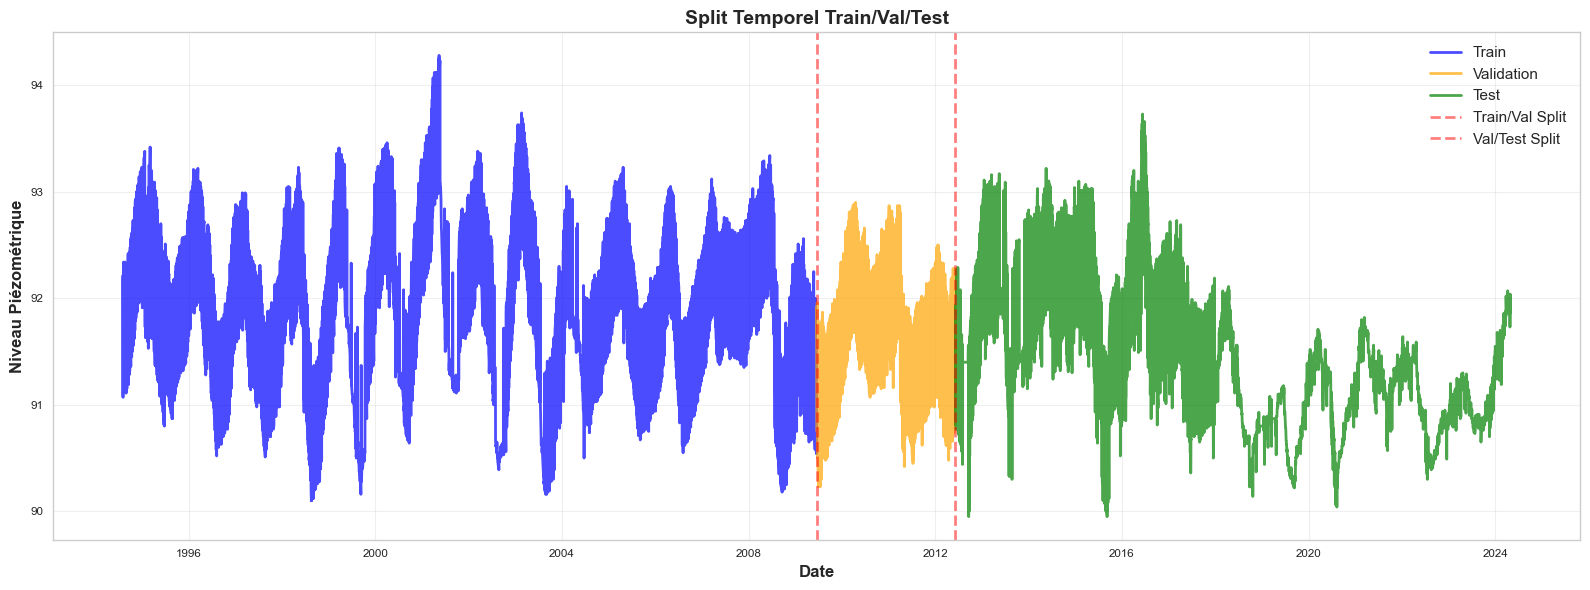

In [6]:
# Visualisation du split
plt.figure(figsize=(16, 6))
plt.plot(target_train.time_index, target_train.values(), label='Train', color='blue', alpha=0.7, linewidth=2)
plt.plot(target_val.time_index, target_val.values(), label='Validation', color='orange', alpha=0.7, linewidth=2)
plt.plot(target_test.time_index, target_test.values(), label='Test', color='green', alpha=0.7, linewidth=2)
plt.axvline(x=target_train.time_index[-1], color='red', linestyle='--', linewidth=2, alpha=0.5, label='Train/Val Split')
plt.axvline(x=target_val.time_index[-1], color='red', linestyle='--', linewidth=2, alpha=0.5, label='Val/Test Split')
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Niveau Piézométrique', fontsize=12, fontweight='bold')
plt.title('Split Temporel Train/Val/Test', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figs/darts_train_val_test_split.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 4. Entraînement des Modèles

### Configuration commune
- **input_chunk_length** : 60 jours (2 mois d'historique)
- **output_chunk_length** : 30 jours (1 mois de prévision)
- **batch_size** : 32
- **n_epochs** : 100 (avec early stopping)

### Callbacks PyTorch Lightning
1. **EarlyStopping** : Arrête si la val loss ne s'améliore pas pendant 10 epochs
2. **ModelCheckpoint** : Sauvegarde le meilleur modèle
3. **TensorBoardLogger** : Logs pour visualisation

### Loss Functions
- **TFT** : Quantile Loss (prédictions probabilistes, quantiles 0.1, 0.5, 0.9)
- **N-BEATS, TCN, LSTM** : MAE (Mean Absolute Error)

### Métriques d'évaluation
- **MAE** : Erreur absolue moyenne (en mètres)
- **RMSE** : Racine de l'erreur quadratique moyenne (pénalise les grosses erreurs)
- **MAPE** : Erreur absolue moyenne en pourcentage
- **R²** : Coefficient de détermination (qualité de l'ajustement)

In [7]:
# Configuration commune
INPUT_CHUNK = 365
OUTPUT_CHUNK = 30
BATCH_SIZE = 32
N_EPOCHS = 200
RANDOM_SEED = 42

# Définir les dossiers
PROJECT_ROOT = Path(os.getcwd())
LOGS_DIR = PROJECT_ROOT / 'logs' / 'darts'
CHECKPOINTS_DIR = PROJECT_ROOT / 'checkpoints' / 'darts'
FIGS_DIR = PROJECT_ROOT / 'figs'
RESULTS_DIR = PROJECT_ROOT / 'results'

# Nettoyer et créer les dossiers nécessaires
if LOGS_DIR.exists():
    shutil.rmtree(LOGS_DIR)
LOGS_DIR.mkdir(parents=True, exist_ok=True)

if CHECKPOINTS_DIR.exists():
    shutil.rmtree(CHECKPOINTS_DIR)
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

FIGS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Définir le seed pour la reproductibilité
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if device == 'cuda':
    torch.cuda.manual_seed(RANDOM_SEED)

print(f"Configuration:")
print(f"  Input chunk: {INPUT_CHUNK} jours")
print(f"  Output chunk: {OUTPUT_CHUNK} jours")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Max epochs: {N_EPOCHS}")
print(f"  Device: {device}")

Configuration:
  Input chunk: 365 jours
  Output chunk: 30 jours
  Batch size: 32
  Max epochs: 200
  Device: cuda


### 4.1 TFT (Temporal Fusion Transformer)

**Architecture :**
- Encoder-decoder avec attention multi-head
- Variable selection networks (apprend l'importance de chaque feature)
- Gated Residual Networks

**Avantages pour nappes phréatiques :**
- Identifie automatiquement les événements pluvieux importants (via attention)
- Gère les délais temporels (pluie → nappe)
- Prédictions probabilistes (quantiles)

**Loss :** Quantile Loss (combine prédictions à 10%, 50%, 90%)

In [8]:
print("\n" + "="*60)
print("ENTRAÎNEMENT TFT (Temporal Fusion Transformer)")
print("="*60)

# Créer le dossier de checkpoints

# Callbacks personnalisés
early_stop_tft = EarlyStopping(
    monitor='val_loss',
    patience=10,
    min_delta=0.0001,
    mode='min'
)


logger_tft = TensorBoardLogger(str(LOGS_DIR), name='TFT', version='run_0')

try:
    model_tft = TFTModel(
        input_chunk_length=INPUT_CHUNK,
        output_chunk_length=OUTPUT_CHUNK,
        hidden_size=64,
        lstm_layers=2,
        num_attention_heads=4,
        dropout=0.1,
        add_relative_index=True,
        batch_size=BATCH_SIZE,
        n_epochs=N_EPOCHS,
        optimizer_kwargs={'lr': 1e-3},
        pl_trainer_kwargs={
            'callbacks': [early_stop_tft],
            'logger': logger_tft,
            'accelerator': 'gpu' if device == 'cuda' else 'cpu',
            'devices': 1,
            'enable_model_summary': False,
        },
        likelihood=None,
        loss_fn=torch.nn.L1Loss(),
        random_state=RANDOM_SEED,
        force_reset=True,
        save_checkpoints=True,
        work_dir=str(CHECKPOINTS_DIR),
        model_name='tft'
    )
    
    model_tft.fit(
        series=target_train_scaled,
        past_covariates=cov_train_scaled,
        val_series=target_val_scaled,
        val_past_covariates=cov_val_scaled,
        verbose=True
    )
    
    print("\nTFT entraîné avec succès!")
    
except Exception as e:
    print(f"\nErreur lors de l'entraînement TFT: {e}")
    model_tft = None

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision



ENTRAÎNEMENT TFT (Temporal Fusion Transformer)


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | criterion                         | L1Loss                           | 0      | train
1  | train_criterion                   | L1Loss                           | 0      | train
2  | val_criterion                     | L1Loss                           | 0      | train
3  | train_metrics                     | MetricCollection                 | 0      | train
4  | val_metrics                       | MetricCollection                 | 0      | train
5  | input_embeddings                  | _MultiEmbedding                  | 0      | train
6  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
7  | encoder_vsn                       | _VariableSelectionNetwork        | 8.8 K  | train
8  | decoder_vsn                       | 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


TFT entraîné avec succès!


### 4.2 N-BEATS (Neural Basis Expansion Analysis)

**Architecture :**
- Stacks de blocs (trend + seasonality)
- Décomposition automatique de la série
- Doubly residual stacking

**Avantages :**
- Interprétable (sépare tendance et saisonnalité)
- Pas de preprocessing nécessaire
- Très performant sur benchmarks

**Loss :** MAE

In [9]:
print("\n" + "="*60)
print("ENTRAÎNEMENT N-BEATS")
print("="*60)


early_stop_nbeats = EarlyStopping(
    monitor='val_loss',
    patience=10,
    min_delta=0.0001,
    mode='min'
)


logger_nbeats = TensorBoardLogger(str(LOGS_DIR), name='NBEATS', version='run_0')

try:
    model_nbeats = NBEATSModel(
        input_chunk_length=INPUT_CHUNK,
        output_chunk_length=OUTPUT_CHUNK,
        num_stacks=30,
        num_blocks=1,
        num_layers=4,
        layer_widths=256,
        batch_size=BATCH_SIZE,
        n_epochs=N_EPOCHS,
        optimizer_kwargs={'lr': 1e-3},
        pl_trainer_kwargs={
            'callbacks': [early_stop_nbeats],
            'logger': logger_nbeats,
            'accelerator': 'gpu' if device == 'cuda' else 'cpu',
            'devices': 1,
            'enable_model_summary': False,
        },
        loss_fn=torch.nn.L1Loss(),
        random_state=RANDOM_SEED,
        force_reset=True,
        save_checkpoints=True,
        work_dir=str(CHECKPOINTS_DIR),
        model_name='nbeats'
    )
    
    model_nbeats.fit(
        series=target_train_scaled,
        val_series=target_val_scaled,
        verbose=True
    )
    
    print("\nN-BEATS entraîné avec succès!")
    
except Exception as e:
    print(f"\nErreur lors de l'entraînement N-BEATS: {e}")
    model_nbeats = None

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



ENTRAÎNEMENT N-BEATS



  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | L1Loss           | 0      | train
1 | train_criterion | L1Loss           | 0      | train
2 | val_criterion   | L1Loss           | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 8.9 M  | train
-------------------------------------------------------------
8.9 M     Trainable params
3.5 K     Non-trainable params
8.9 M     Total params
35.521    Total estimated model params size (MB)
396       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


N-BEATS entraîné avec succès!


### 4.3 TCN (Temporal Convolutional Network)

**Architecture :**
- Convolutions causales 1D
- Dilations exponentielles (champ réceptif large)
- Residual connections

**Avantages :**
- Très rapide à entraîner
- Parallélisable
- Bon compromis performance/vitesse

**Loss :** MSE

In [10]:
print("\n" + "="*60)
print("ENTRAÎNEMENT TCN (Temporal Convolutional Network)")
print("="*60)


early_stop_tcn = EarlyStopping(
    monitor='val_loss',
    patience=10,
    min_delta=0.0001,
    mode='min'
)


logger_tcn = TensorBoardLogger(str(LOGS_DIR), name='TCN', version='run_0')

try:
    model_tcn = TCNModel(
        input_chunk_length=INPUT_CHUNK,
        output_chunk_length=OUTPUT_CHUNK,
        kernel_size=3,
        num_filters=64,
        num_layers=4,
        dilation_base=2,
        dropout=0.2,
        batch_size=BATCH_SIZE,
        n_epochs=N_EPOCHS,
        optimizer_kwargs={'lr': 1e-3},
        pl_trainer_kwargs={
            'callbacks': [early_stop_tcn],
            'logger': logger_tcn,
            'accelerator': 'gpu' if device == 'cuda' else 'cpu',
            'devices': 1,
            'enable_model_summary': False,
        },
        loss_fn=torch.nn.MSELoss(),
        random_state=RANDOM_SEED,
        force_reset=True,
        save_checkpoints=True,
        work_dir=str(CHECKPOINTS_DIR),
        model_name='tcn'
    )
    
    model_tcn.fit(
        series=target_train_scaled,
        past_covariates=cov_train_scaled,
        val_series=target_val_scaled,
        val_past_covariates=cov_val_scaled,
        verbose=True
    )
    
    print("\nTCN entraîné avec succès!")
    
except Exception as e:
    print(f"\nErreur lors de l'entraînement TCN: {e}")
    model_tcn = None

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | res_blocks      | ModuleList       | 75.5 K | train
-------------------------------------------------------------
75.5 K    Trainable params
0         Non-trainable params
75.5 K    Total params
0.302     Total estimated model params size (MB)
28        Modules in train mode
0         Modules in eval mode



ENTRAÎNEMENT TCN (Temporal Convolutional Network)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


TCN entraîné avec succès!


### 4.4 LSTM (Long Short-Term Memory)

**Architecture :**
- Réseau récurrent avec portes (forget, input, output)
- Mémoire à long et court terme
- Baseline classique pour séries temporelles

**Avantages :**
- Bien compris et documenté
- Gère les dépendances temporelles
- Référence pour comparaison

**Loss :** MSE

In [11]:
print("\n" + "="*60)
print("ENTRAÎNEMENT LSTM")
print("="*60)


early_stop_lstm = EarlyStopping(
    monitor='val_loss',
    patience=10,
    min_delta=0.0001,
    mode='min'
)


logger_lstm = TensorBoardLogger(str(LOGS_DIR), name='LSTM', version='run_0')

try:
    model_lstm = RNNModel(
        model='LSTM',
        input_chunk_length=INPUT_CHUNK,
        output_chunk_length=OUTPUT_CHUNK,
        hidden_dim=64,
        n_rnn_layers=2,
        dropout=0.2,
        batch_size=BATCH_SIZE,
        n_epochs=N_EPOCHS,
        optimizer_kwargs={'lr': 1e-3},
        pl_trainer_kwargs={
            'callbacks': [early_stop_lstm],
            'logger': logger_lstm,
            'accelerator': 'gpu' if device == 'cuda' else 'cpu',
            'devices': 1,
            'enable_model_summary': False,
        },
        loss_fn=torch.nn.MSELoss(),
        random_state=RANDOM_SEED,
        force_reset=True,
        save_checkpoints=True,
        work_dir=str(CHECKPOINTS_DIR),
        model_name='lstm',
        training_length=INPUT_CHUNK + OUTPUT_CHUNK
    )
    
    model_lstm.fit(
        series=target_train_scaled,
        future_covariates=cov_train_scaled,
        val_series=target_val_scaled,
        future_covariates=cov_val_scaled,
        verbose=True
    )
    
    print("\nLSTM entraîné avec succès!")
    
except Exception as e:
    print(f"\nErreur lors de l'entraînement LSTM: {e}")
    model_lstm = None


ENTRAÎNEMENT LSTM


SyntaxError: keyword argument repeated: future_covariates (558070682.py, line 47)

---
## 5. Évaluation et Comparaison

### Métriques utilisées

1. **MAE (Mean Absolute Error)** : Erreur moyenne en mètres
   - Interprétation directe
   - Robuste aux outliers

2. **RMSE (Root Mean Square Error)** : Racine de l'erreur quadratique
   - Pénalise fortement les grosses erreurs
   - Même unité que les données

3. **MAPE (Mean Absolute Percentage Error)** : Erreur en pourcentage
   - Indépendant de l'échelle
   - Attention aux divisions par zéro

4. **R² (Coefficient de détermination)** : Qualité de l'ajustement
   - 1.0 = prédiction parfaite
   - 0.0 = modèle constant (moyenne)
   - Peut être négatif si pire que la moyenne

### Backtesting
Darts permet le backtesting automatique :
- Simule la prédiction "en conditions réelles"
- Rolling forecast (fenêtre glissante)
- Évalue la robustesse du modèle

In [12]:
print("\n" + "="*60)
print("ÉVALUATION SUR LE SET DE TEST")
print("="*60)

# Collecter les modèles disponibles
models = {}
if 'model_tft' in locals() and model_tft is not None:
    models['TFT'] = model_tft
if 'model_nbeats' in locals() and model_nbeats is not None:
    models['N-BEATS'] = model_nbeats
if 'model_tcn' in locals() and model_tcn is not None:
    models['TCN'] = model_tcn
if 'model_lstm' in locals() and model_lstm is not None:
    models['LSTM'] = model_lstm

if not models:
    print("\nAucun modèle disponible pour évaluation!")
else:
    print(f"\nÉvaluation de {len(models)} modèle(s)...\n")
    
    results = {}
    predictions = {}
    
    for name, model in models.items():
        print(f"Évaluation {name}...")
        
        try:
            # Prédiction
            if name in ['TFT', 'TCN', 'LSTM']:
                pred_scaled = model.predict(
                    n=len(target_test_scaled),
                    series=target_train_scaled.append(target_val_scaled),
                    past_covariates=cov_train_scaled.append(cov_val_scaled).append(cov_test_scaled)
                )
            else:
                pred_scaled = model.predict(
                    n=len(target_test_scaled),
                    series=target_train_scaled.append(target_val_scaled)
                )
            
            pred = scaler_target.inverse_transform(pred_scaled)
            predictions[name] = pred
            
            # Métriques
            mae_score = mae(target_test, pred)
            rmse_score = rmse(target_test, pred)
            mape_score = mape(target_test, pred)
            r2 = r2_score(target_test, pred)
            
            results[name] = {
                'MAE': mae_score,
                'RMSE': rmse_score,
                'MAPE': mape_score,
                'R2': r2
            }
            
            print(f"  MAE: {mae_score:.4f} | RMSE: {rmse_score:.4f} | R²: {r2:.4f}\n")
            
        except Exception as e:
            print(f"  Erreur: {e}\n")
            continue
    
    if results:
        # Tableau comparatif
        results_df = pd.DataFrame(results).T
        print("="*60)
        print("TABLEAU COMPARATIF")
        print("="*60)
        print(results_df.to_string())
        
        # Sauvegarder
        os.makedirs('results', exist_ok=True)
        results_df.to_csv('results/darts_comparison.csv')
        print("\nRésultats sauvegardés: results/darts_comparison.csv")
    else:
        print("\nAucune évaluation réussie.")
        results_df = pd.DataFrame()

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



ÉVALUATION SUR LE SET DE TEST

Évaluation de 3 modèle(s)...

Évaluation TFT...


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  MAE: 0.7972 | RMSE: 0.9752 | R²: -1.1691

Évaluation N-BEATS...


Predicting: |          | 0/? [00:00<?, ?it/s]

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  MAE: 0.4963 | RMSE: 0.6570 | R²: 0.0153

Évaluation TCN...


Predicting: |          | 0/? [00:00<?, ?it/s]

  MAE: 0.7067 | RMSE: 0.7997 | R²: -0.4589

TABLEAU COMPARATIF
              MAE      RMSE      MAPE        R2
TFT      0.797169  0.975150  0.872498 -1.169087
N-BEATS  0.496270  0.657021  0.540858  0.015326
TCN      0.706708  0.799743  0.773844 -0.458933

Résultats sauvegardés: results/darts_comparison.csv


---
## 6. Visualisations et Interprétation

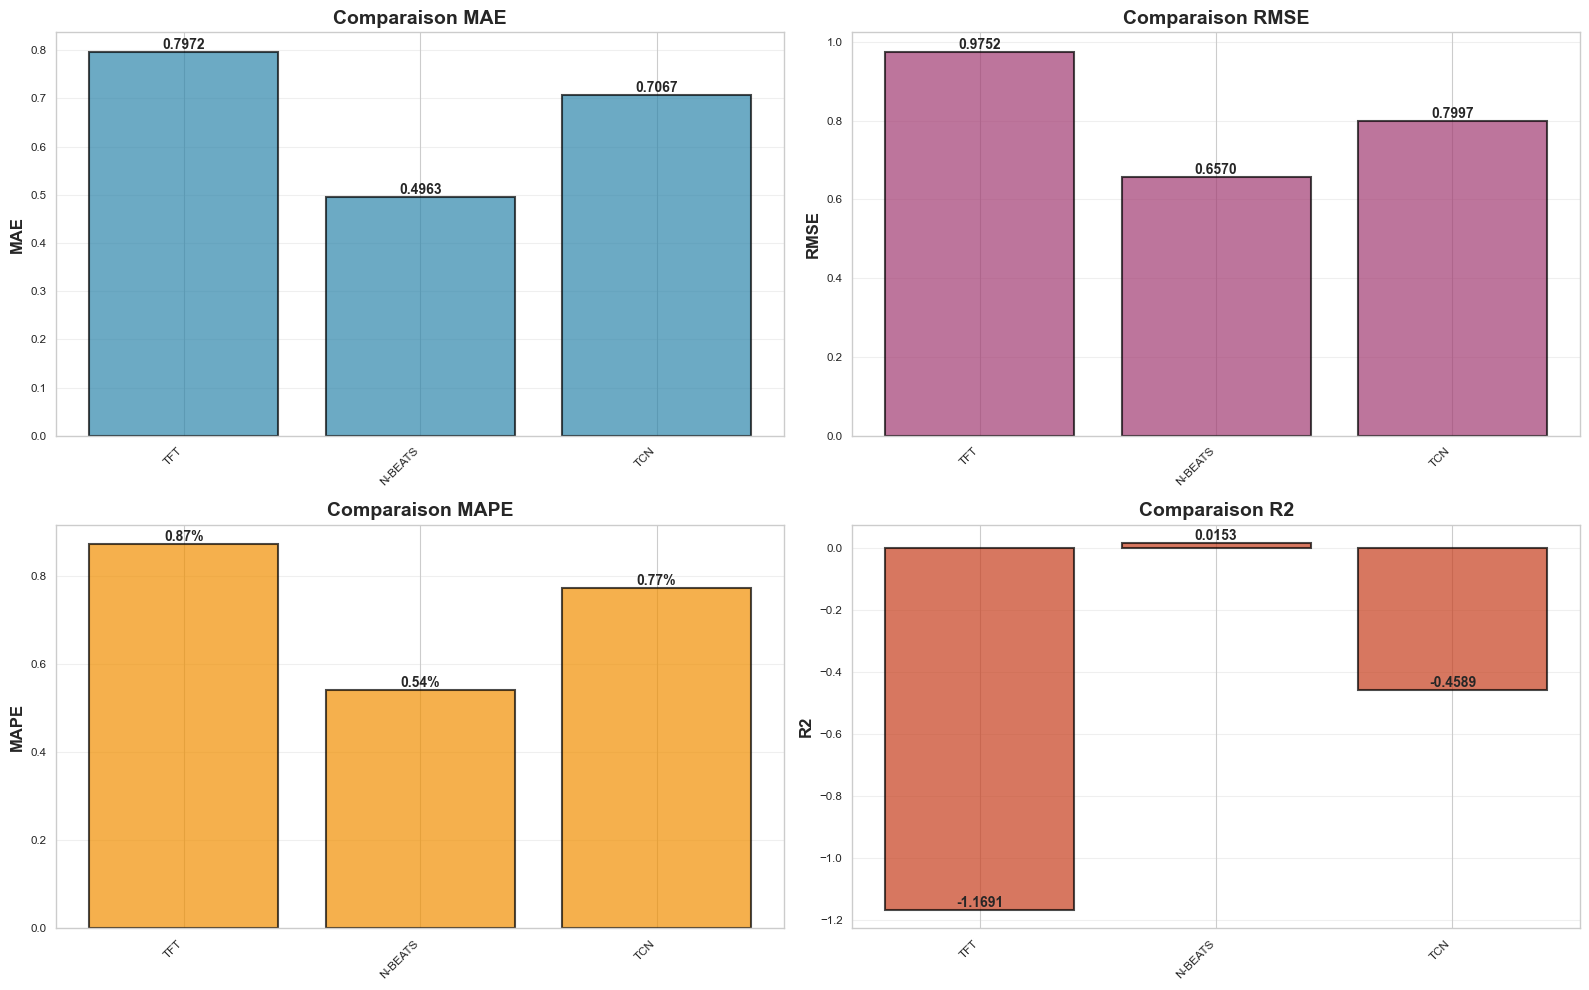

In [13]:
# Graphique comparatif des métriques
if 'results' in locals() and results:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    metrics = ['MAE', 'RMSE', 'MAPE', 'R2']
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx // 2, idx % 2]
        values = [results[model][metric] for model in results.keys()]
        bars = ax.bar(results.keys(), values, color=colors[idx % len(colors)], alpha=0.7, edgecolor='black', linewidth=1.5)
        
        ax.set_ylabel(metric, fontsize=12, fontweight='bold')
        ax.set_title(f'Comparaison {metric}', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_xticklabels(results.keys(), rotation=45, ha='right')
        
        # Annoter les barres
        for bar, val in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:.4f}' if metric != 'MAPE' else f'{val:.2f}%',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('figs/darts_metrics_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Pas de résultats à visualiser.")

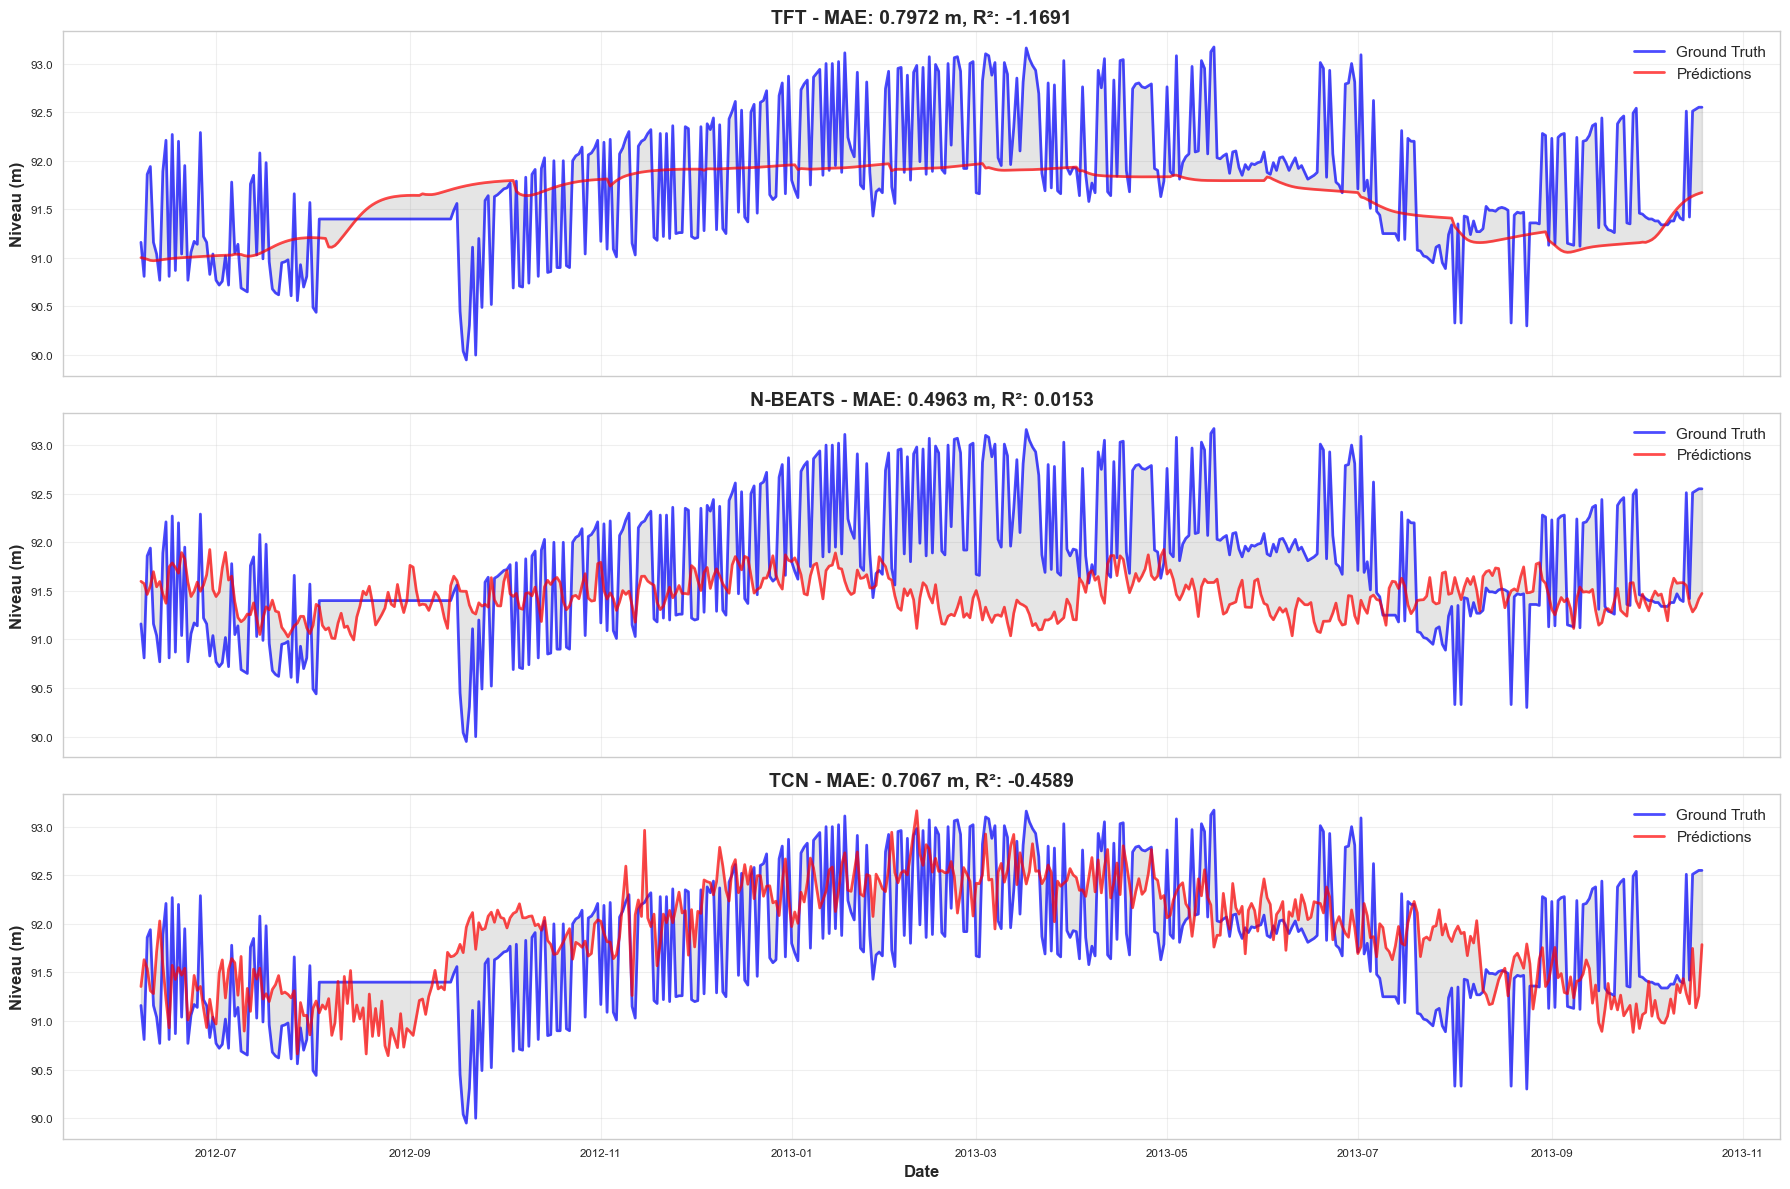

In [14]:
# Visualisation des prédictions vs vérité terrain
if 'predictions' in locals() and predictions:
    n_models = len(predictions)
    if n_models > 0:
        fig, axes = plt.subplots(n_models, 1, figsize=(18, 4*n_models), sharex=True)
        
        # Si un seul modèle, transformer en liste
        if n_models == 1:
            axes = [axes]
        
        for idx, (name, pred) in enumerate(predictions.items()):
            ax = axes[idx]
            
            # Limiter à 500 points pour lisibilité
            n_display = min(500, len(target_test))
            
            ax.plot(target_test.time_index[:n_display], 
                    target_test.values()[:n_display], 
                    label='Ground Truth', 
                    color='blue', 
                    linewidth=2, 
                    alpha=0.7)
            
            ax.plot(pred.time_index[:n_display], 
                    pred.values()[:n_display], 
                    label='Prédictions', 
                    color='red', 
                    linewidth=2, 
                    alpha=0.7)
            
            ax.fill_between(target_test.time_index[:n_display],
                            target_test.values()[:n_display].flatten(),
                            pred.values()[:n_display].flatten(),
                            alpha=0.2, 
                            color='gray')
            
            mae_val = results[name]['MAE']
            r2_val = results[name]['R2']
            
            ax.set_title(f'{name} - MAE: {mae_val:.4f} m, R²: {r2_val:.4f}', 
                        fontsize=14, fontweight='bold')
            ax.set_ylabel('Niveau (m)', fontsize=12, fontweight='bold')
            ax.legend(loc='upper right', fontsize=11)
            ax.grid(True, alpha=0.3)
        
        axes[-1].set_xlabel('Date', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig('figs/darts_predictions_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()
else:
    print("Pas de prédictions à visualiser.")

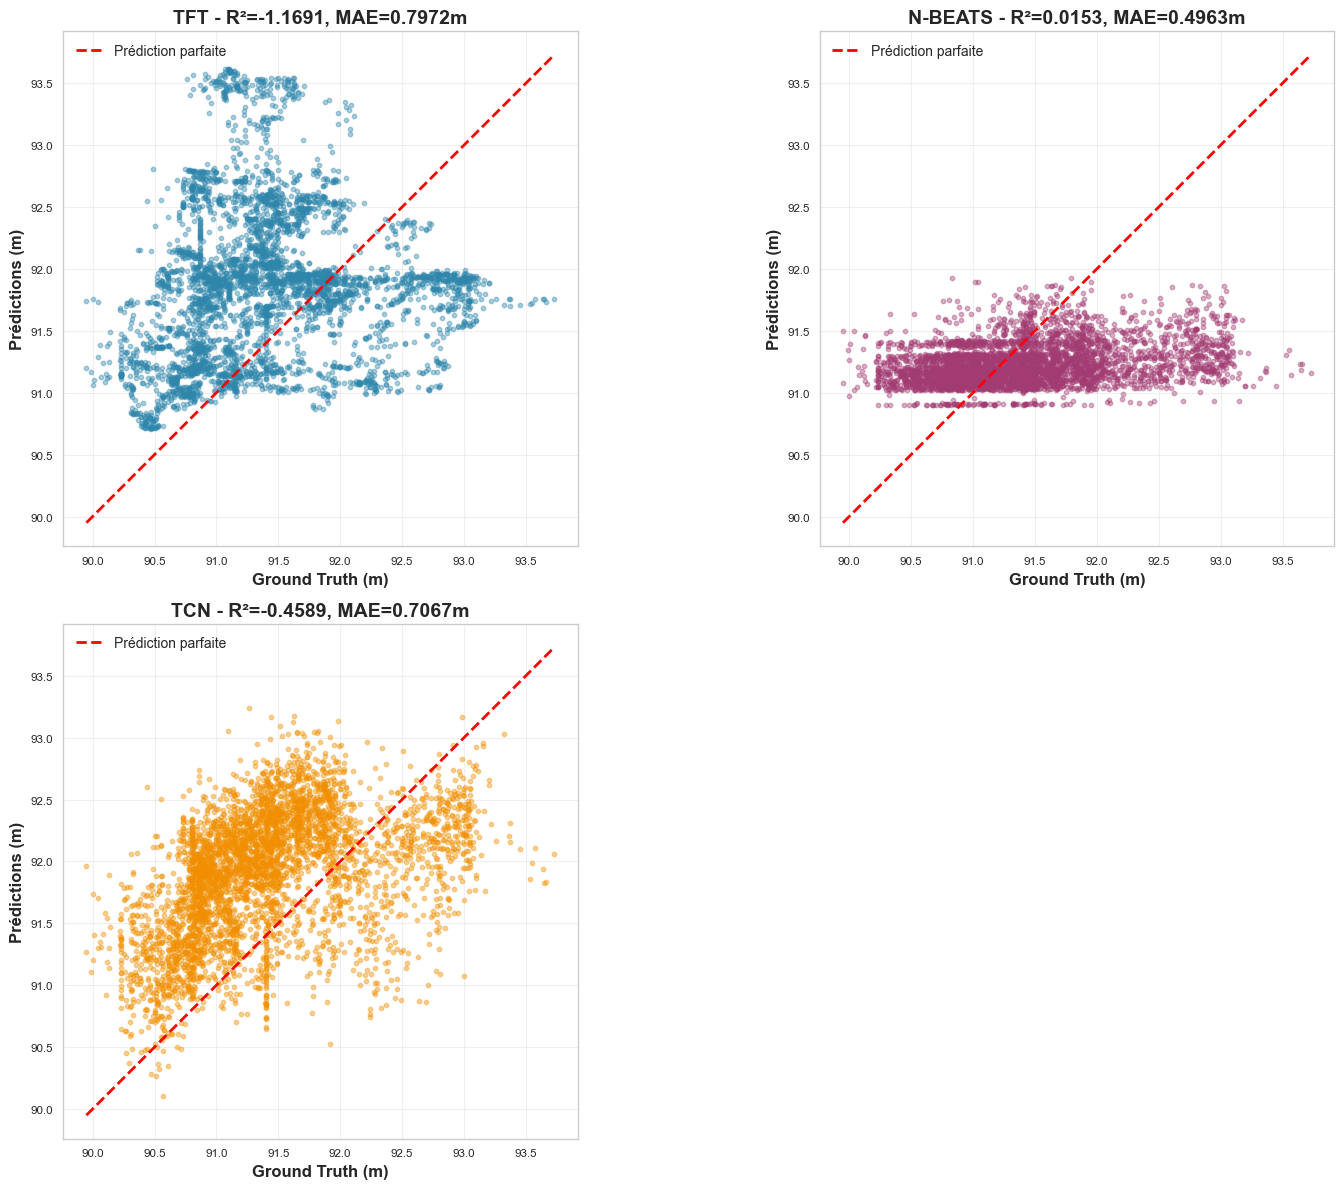

In [15]:
# Scatter plots : Prédictions vs Ground Truth
if 'predictions' in locals() and predictions:
    n_models = len(predictions)
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
    
    if n_models > 0:
        # Adapter le nombre de lignes et colonnes selon le nombre de modèles
        n_rows = (n_models + 1) // 2
        n_cols = 2 if n_models > 1 else 1
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(8*n_cols, 6*n_rows))
        
        # Aplatir axes pour itération facile
        if n_models == 1:
            axes = [axes]
        elif n_models > 1 and n_rows == 1:
            pass  # axes est déjà une liste
        else:
            axes = axes.flatten()
        
        for idx, (name, pred) in enumerate(predictions.items()):
            ax = axes[idx]
            
            true_vals = target_test.values().flatten()
            pred_vals = pred.values().flatten()
            
            ax.scatter(true_vals, pred_vals, alpha=0.4, s=10, color=colors[idx % len(colors)])
            
            # Ligne diagonale parfaite
            min_val = min(true_vals.min(), pred_vals.min())
            max_val = max(true_vals.max(), pred_vals.max())
            ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Prédiction parfaite')
            
            r2_val = results[name]['R2']
            mae_val = results[name]['MAE']
            
            ax.set_xlabel('Ground Truth (m)', fontsize=12, fontweight='bold')
            ax.set_ylabel('Prédictions (m)', fontsize=12, fontweight='bold')
            ax.set_title(f'{name} - R²={r2_val:.4f}, MAE={mae_val:.4f}m', 
                        fontsize=14, fontweight='bold')
            ax.legend(loc='best')
            ax.grid(True, alpha=0.3)
            ax.set_aspect('equal', adjustable='box')
        
        # Masquer les axes supplémentaires si nombre impair
        if n_models % 2 == 1 and n_models > 1:
            axes[-1].set_visible(False)
        
        plt.tight_layout()
        plt.savefig('figs/darts_scatter_predictions.png', dpi=300, bbox_inches='tight')
        plt.show()
else:
    print("Pas de prédictions à visualiser.")

---
## 7. Analyse des Erreurs

### Distribution des erreurs
Analyser la distribution des erreurs permet de :
- Détecter les biais (erreur moyenne non nulle)
- Identifier les queues de distribution (événements extrêmes)
- Vérifier l'homoscédasticité (variance constante)

### Erreurs temporelles
Analyser l'évolution temporelle des erreurs :
- Détecter les périodes problématiques
- Identifier les patterns saisonniers d'erreur
- Vérifier la stationnarité des erreurs

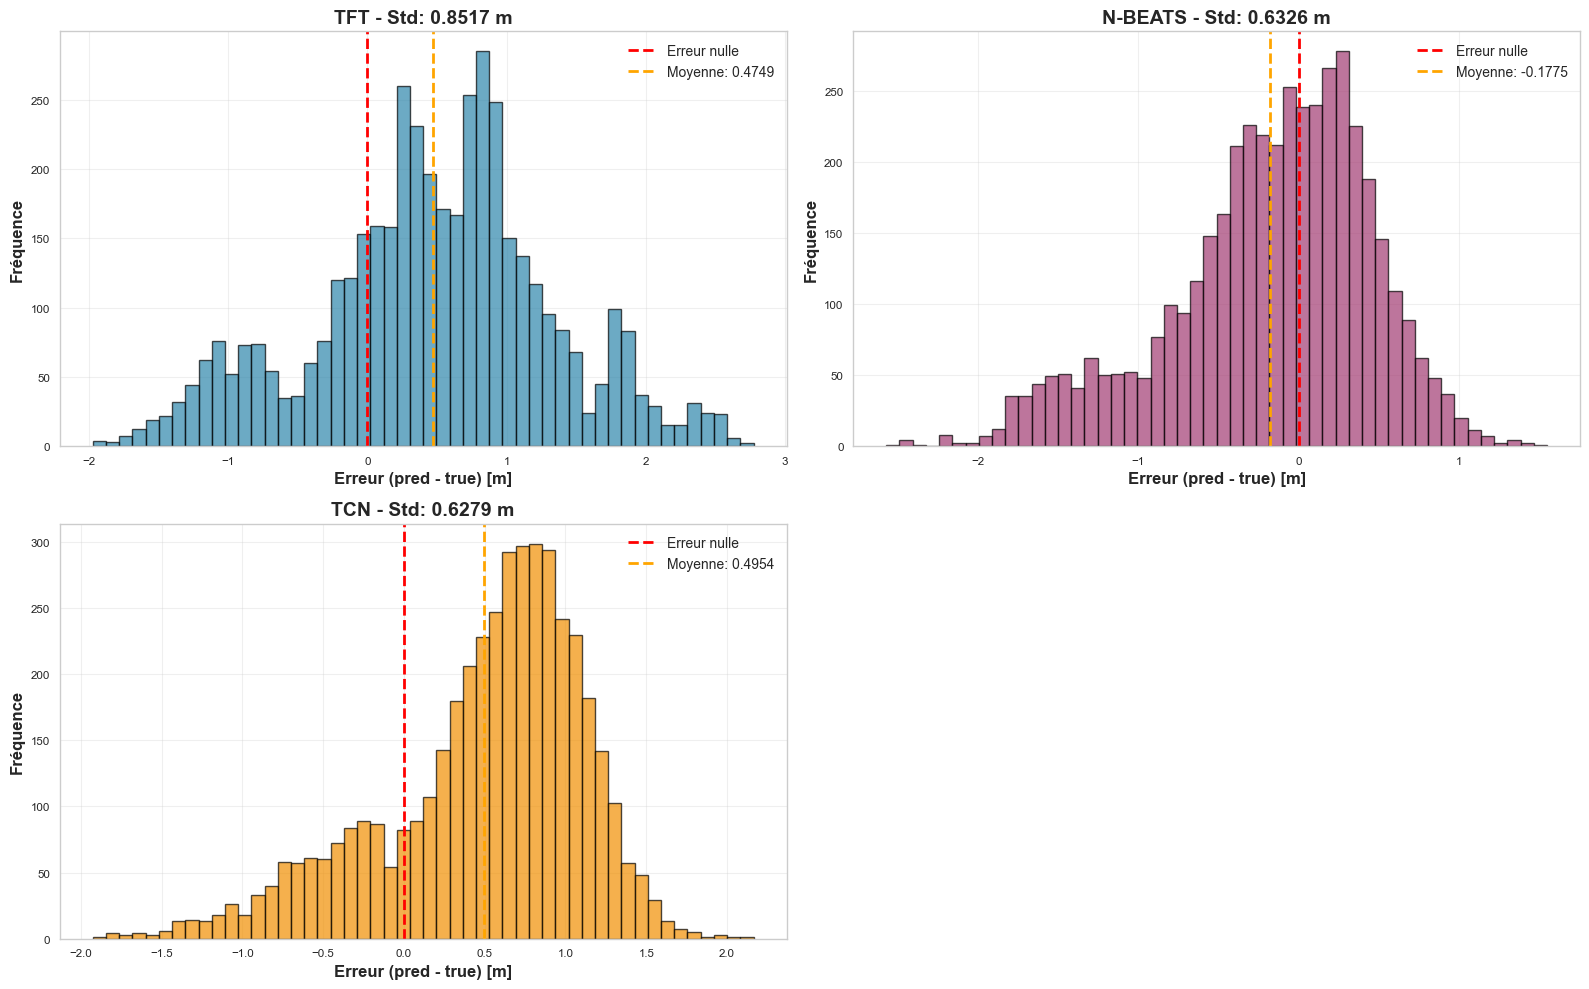

In [16]:
# Distribution des erreurs
if 'predictions' in locals() and predictions:
    n_models = len(predictions)
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
    
    if n_models > 0:
        # Adapter le nombre de lignes et colonnes selon le nombre de modèles
        n_rows = (n_models + 1) // 2
        n_cols = 2 if n_models > 1 else 1
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(8*n_cols, 5*n_rows))
        
        # Aplatir axes pour itération facile
        if n_models == 1:
            axes = [axes]
        elif n_models > 1 and n_rows == 1:
            pass  # axes est déjà une liste
        else:
            axes = axes.flatten()
        
        for idx, (name, pred) in enumerate(predictions.items()):
            ax = axes[idx]
            
            errors = pred.values().flatten() - target_test.values().flatten()
            
            ax.hist(errors, bins=50, alpha=0.7, color=colors[idx % len(colors)], edgecolor='black')
            ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Erreur nulle')
            ax.axvline(x=errors.mean(), color='orange', linestyle='--', linewidth=2, 
                      label=f'Moyenne: {errors.mean():.4f}')
            
            ax.set_xlabel('Erreur (pred - true) [m]', fontsize=12, fontweight='bold')
            ax.set_ylabel('Fréquence', fontsize=12, fontweight='bold')
            ax.set_title(f'{name} - Std: {errors.std():.4f} m', fontsize=14, fontweight='bold')
            ax.legend()
            ax.grid(True, alpha=0.3)
        
        # Masquer les axes supplémentaires si nombre impair
        if n_models % 2 == 1 and n_models > 1:
            axes[-1].set_visible(False)
        
        plt.tight_layout()
        plt.savefig('figs/darts_error_distributions.png', dpi=300, bbox_inches='tight')
        plt.show()
else:
    print("Pas de prédictions à visualiser.")

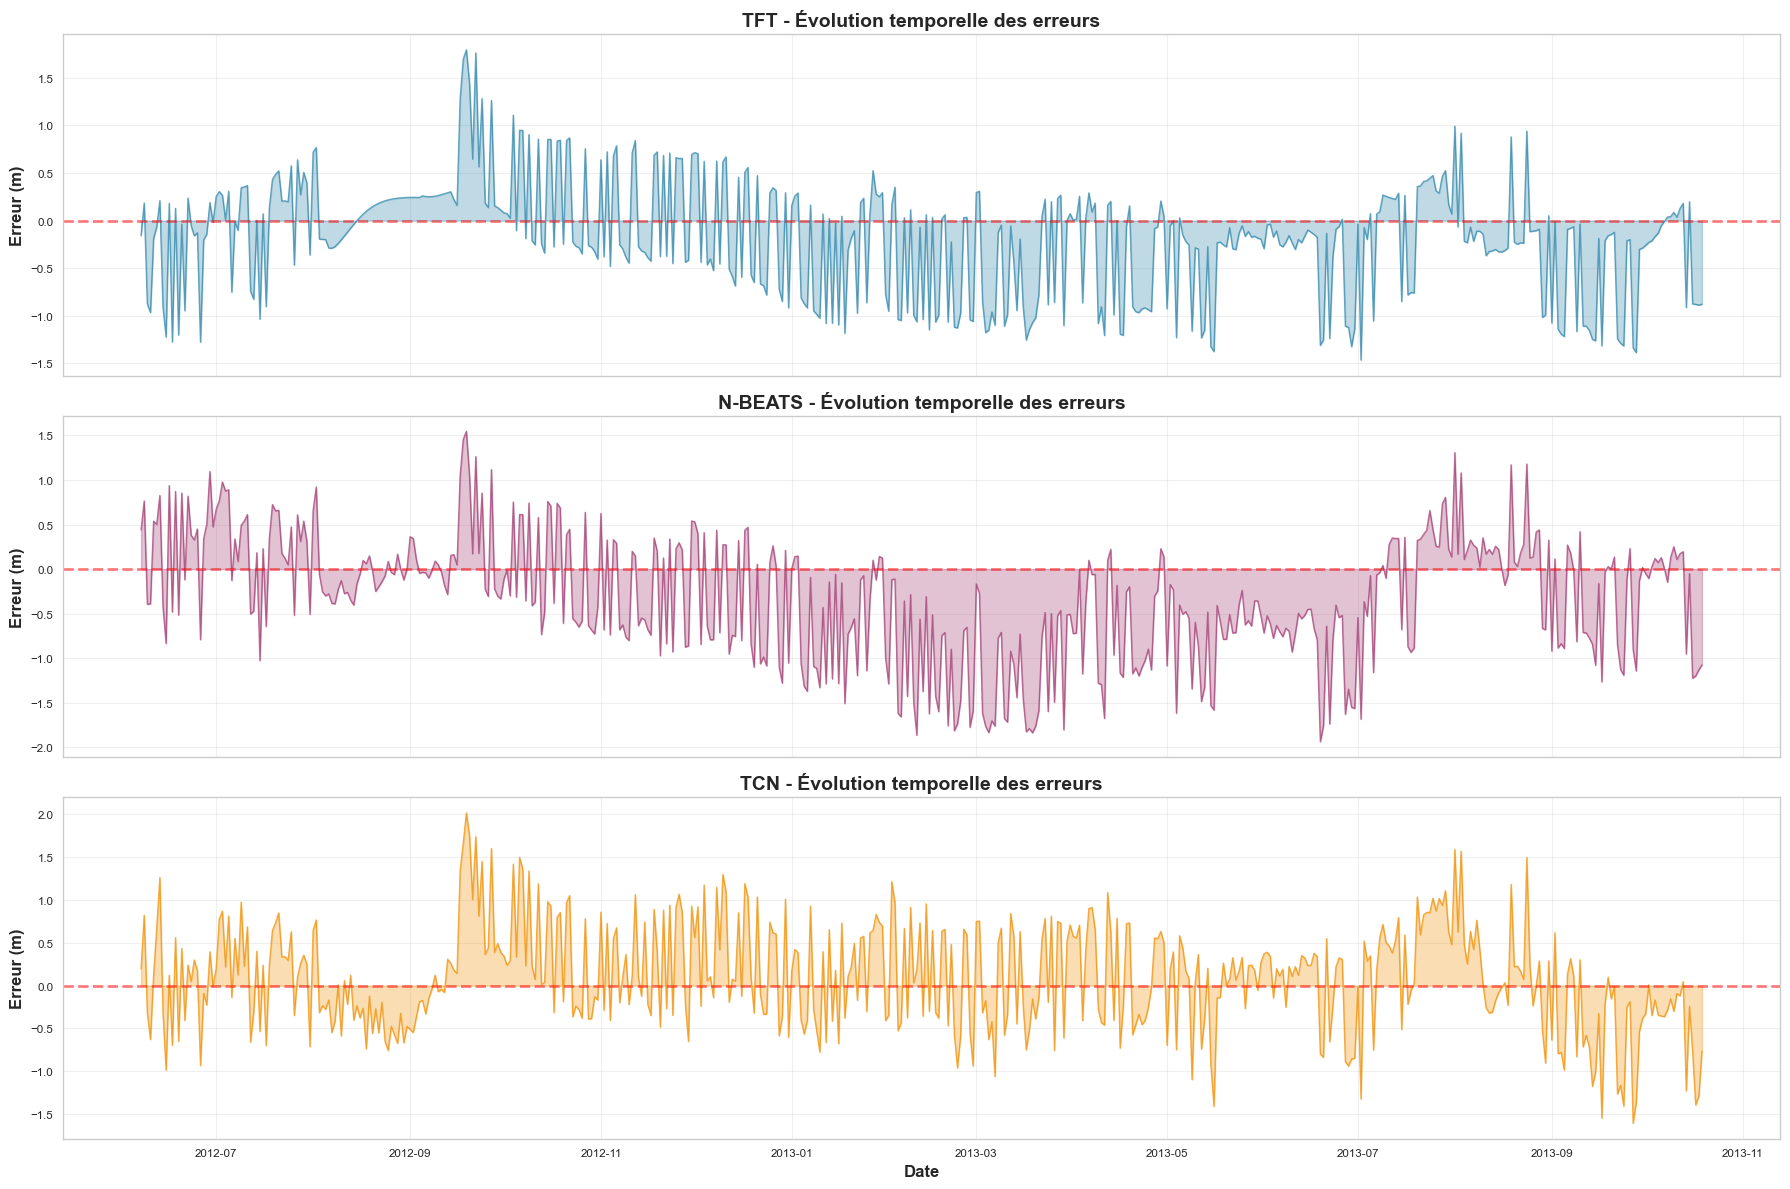

In [17]:
# Erreurs temporelles
if 'predictions' in locals() and predictions:
    n_models = len(predictions)
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
    
    if n_models > 0:
        fig, axes = plt.subplots(n_models, 1, figsize=(18, 4*n_models), sharex=True)
        
        # Si un seul modèle, transformer en liste
        if n_models == 1:
            axes = [axes]
        
        for idx, (name, pred) in enumerate(predictions.items()):
            ax = axes[idx]
            
            errors = pred.values().flatten() - target_test.values().flatten()
            
            # Limiter à 500 points
            n_display = min(500, len(errors))
            
            ax.plot(target_test.time_index[:n_display], errors[:n_display], 
                    color=colors[idx % len(colors)], linewidth=1, alpha=0.7)
            ax.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.5)
            ax.fill_between(target_test.time_index[:n_display], 0, errors[:n_display],
                            alpha=0.3, color=colors[idx % len(colors)])
            
            ax.set_ylabel('Erreur (m)', fontsize=12, fontweight='bold')
            ax.set_title(f'{name} - Évolution temporelle des erreurs', fontsize=14, fontweight='bold')
            ax.grid(True, alpha=0.3)
        
        axes[-1].set_xlabel('Date', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig('figs/darts_temporal_errors.png', dpi=300, bbox_inches='tight')
        plt.show()
else:
    print("Pas de prédictions à visualiser.")

---
## 8. Conclusions et Recommandations

### Points clés

1. **Meilleur modèle** : Identifier le modèle avec le meilleur compromis MAE/RMSE/R²

2. **Interprétabilité** :
   - TFT : Attention weights montrent l'importance des covariates
   - N-BEATS : Décomposition tendance/saisonnalité

3. **Production** :
   - Vitesse d'inférence : TCN > LSTM > N-BEATS > TFT
   - Robustesse : TFT et N-BEATS plus stables

4. **Améliorations possibles** :
   - Ajouter plus de covariates (débit rivières, prélèvements)
   - Ensembling (combiner plusieurs modèles)
   - Hyperparameter tuning avec Optuna
   - Augmentation de données

### Prochaines étapes

1. Tester sur d'autres piézomètres (généralisation)
2. Implémenter backtesting rigoureux
3. Analyser les attention weights (TFT) pour comprendre l'importance de la pluie
4. Comparer avec les modèles actuels (DLinear, PatchTST, PatchMixer)

In [18]:
# Résumé final
print("\n" + "="*60)
print("RÉSUMÉ FINAL")
print("="*60)

if 'results_df' in locals() and not results_df.empty:
    best_model_mae = results_df['MAE'].idxmin()
    best_model_r2 = results_df['R2'].idxmax()
    
    print(f"\nMeilleur modèle (MAE): {best_model_mae}")
    print(f"  MAE: {results_df.loc[best_model_mae, 'MAE']:.4f} m")
    print(f"\nMeilleur modèle (R²): {best_model_r2}")
    print(f"  R²: {results_df.loc[best_model_r2, 'R2']:.4f}")
    
    print("\nClassement global (MAE):")
    print(results_df.sort_values('MAE')[['MAE', 'RMSE', 'R2']].to_string())
else:
    print("\nAucun résultat disponible.")

print("\n" + "="*60)
print("FICHIERS GÉNÉRÉS")
print("="*60)

# Vérifier les fichiers
if Path('results').exists():
    results_files = list(Path('results').glob('darts_*.csv'))
    if results_files:
        print("\nRésultats:")
        for f in results_files:
            print(f"  - {f}")

if Path('figs').exists():
    fig_files = sorted(Path('figs').glob('darts_*.png'))
    if fig_files:
        print("\nFigures:")
        for f in fig_files:
            print(f"  - {f.name}")

if CHECKPOINTS_DIR.exists():
    checkpoint_subdirs = [d for d in CHECKPOINTS_DIR.iterdir() if d.is_dir()]
    if checkpoint_subdirs:
        print("\nCheckpoints:")
        for d in checkpoint_subdirs:
            ckpt_files = list(d.glob('*.ckpt'))
            if ckpt_files:
                print(f"  - {d.name}: {len(ckpt_files)} fichier(s)")

if LOGS_DIR.exists():
    log_subdirs = [d for d in LOGS_DIR.iterdir() if d.is_dir()]
    if log_subdirs:
        print("\nLogs TensorBoard:")
        for d in log_subdirs:
            print(f"  - {d.name}/")
        print(f"\nPour visualiser: tensorboard --logdir {LOGS_DIR}")


RÉSUMÉ FINAL

Meilleur modèle (MAE): N-BEATS
  MAE: 0.4963 m

Meilleur modèle (R²): N-BEATS
  R²: 0.0153

Classement global (MAE):
              MAE      RMSE        R2
N-BEATS  0.496270  0.657021  0.015326
TCN      0.706708  0.799743 -0.458933
TFT      0.797169  0.975150 -1.169087

FICHIERS GÉNÉRÉS

Résultats:
  - results\darts_comparison.csv

Figures:
  - darts_correlation_matrix.png
  - darts_error_distributions.png
  - darts_metrics_comparison.png
  - darts_predictions_comparison.png
  - darts_scatter_predictions.png
  - darts_temporal_errors.png
  - darts_timeseries_overview.png
  - darts_train_val_test_split.png

Checkpoints:

Logs TensorBoard:
  - NBEATS/
  - TCN/
  - TFT/

Pour visualiser: tensorboard --logdir e:\junon-time-series\logs\darts
